[reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

## AdaBoost Hyperparameters and Tuning

After understanding how AdaBoost works internally, the next step is to understand how to control its behavior using hyperparameters.

---

## Key Hyperparameters in AdaBoost

### 1. n_estimators

- Number of weak learners (decision stumps)
- Default: 50

#### Effect:
- Low value → underfitting
- High value → better learning but risk of overfitting

---

### 2. learning_rate

- Scales the contribution of each model

$$
H(x) = \text{sign} \left( \sum_{t=1}^{T} \eta \cdot \alpha_t \cdot h_t(x) \right)
$$

where:
- $$\eta$$ = learning_rate  
- $$\alpha_t$$ = model weight  
- $$h_t(x)$$ = prediction of t-th weak learner  

#### Effect:
- Small value → slower learning, more stable
- Large value → faster learning, may overfit

---

### 3. base_estimator (or estimator)

- The weak learner used (usually decision tree)

Example:
```python
DecisionTreeClassifier(max_depth=1)

## Base Estimator and Algorithm

### Effect of Tree Depth

- `max_depth = 1` → Decision stump (default and preferred)  
- Higher depth → Stronger learners but reduces the boosting effect  

---

### Algorithm

- **SAMME** → Used for multi-class classification  
- **SAMME.R** → Uses class probabilities (more efficient and commonly used)  

---

## Important Trade-off

There is a relationship between:

- `n_estimators`
- `learning_rate`

---

### Rule of Thumb

- Small `learning_rate` → Increase `n_estimators`  
- Large `learning_rate` → Decrease `n_estimators`  

## example 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

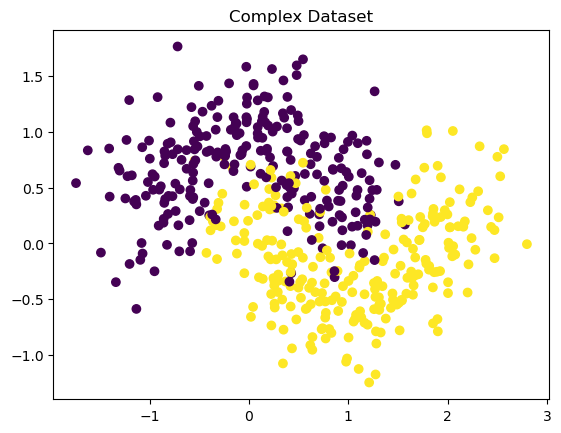

In [63]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=500,
    noise=0.3,   
    random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Complex Dataset")
plt.show()

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
base_estimator = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1
)

In [66]:
model.fit(X_train , y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [67]:
y_pred = model.predict(X_test)

In [68]:
baseline_acc = accuracy_score(y_test , y_pred)
print("Accuracy - Baseline:  ", baseline_acc)

Accuracy - Baseline:   0.89


In [69]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Decision Boundary")
    plt.show()

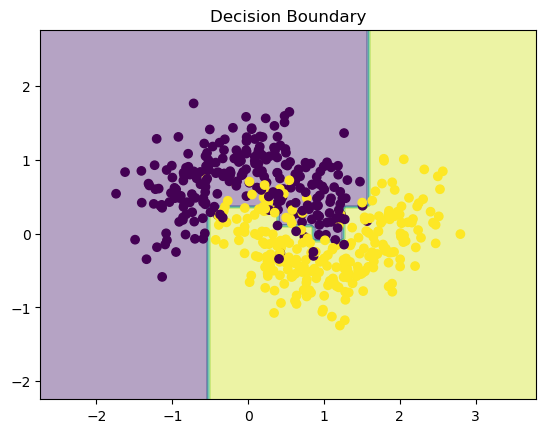

In [70]:
plot_decision_boundary(model, X, y)

In [71]:
abc = AdaBoostClassifier(n_estimators = 1500)
abc.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",1500
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


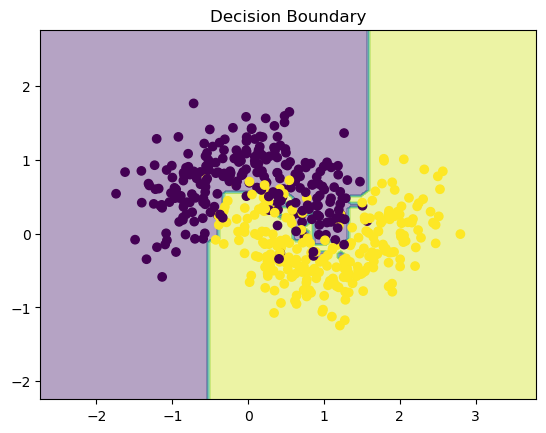

In [72]:
plot_decision_boundary(abc, X,y)

In [73]:
y_pred1 = abc.predict(X_test)

In [74]:
accuracy_score(y_test , y_pred1)

0.88

## Effect of Decreasing Learning Rate

Reducing the learning rate (η) applies a **shrinkage effect** on model contribution.

---

### What happens mathematically

$$
H(x) = \text{sign} \left( \sum_{t=1}^{T} \eta \cdot \alpha_t \cdot h_t(x) \right)
$$

- $$\eta$$ = learning_rate  
- $$\alpha_t$$ = model weight  

---

### Key Effect

- Smaller learning_rate → reduces the impact of each weak learner  
- Effectively scales down $$\alpha_t$$  

---

### Important Clarification

Learning rate does NOT directly reduce sample weights.

Instead:

- It reduces the influence of each model in the final prediction  
- Weight updates become less aggressive indirectly  

---

### Intuition

- Large learning_rate → fast learning, aggressive updates  
- Small learning_rate → slow learning, more stable  

---

### Trade-off

- Small learning_rate:
  - Needs more estimators  
  - Better generalization  

- Large learning_rate:
  - Fewer estimators needed  
  - Risk of overfitting  

---

##

Learning rate controls **how much each model contributes**, not the sample weights directly.

In [75]:
ab = AdaBoostClassifier(n_estimators =1500 , learning_rate=0.1)
ab.fit(X_train , y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",1500
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


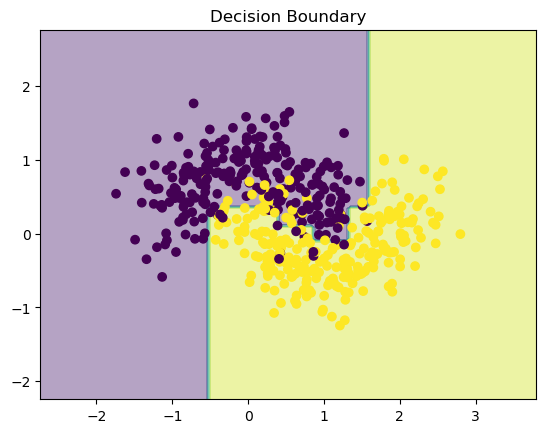

In [76]:
plot_decision_boundary(ab , X,y)

In [77]:
y_pred1 = ab.predict(X_test)
accuracy_score(y_test , y_pred1)

0.89

## let's apply gridSearchCV

In [79]:
from sklearn.tree import DecisionTreeClassifier

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier()
)

In [87]:
params = {
    'n_estimators': [10, 50, 100, 500],
    'learning_rate': [0.001, 0.01, 0.1, 1],
    'estimator__max_depth': [1, 2, 3],
}

In [88]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    n_jobs=-1,
    cv=5,
    scoring='accuracy'
)

In [89]:
grid_result = grid_search.fit(X_train , y_train)

In [90]:
print("Best : " , grid_search.best_score_ , grid_result.best_params_)

Best :  0.915 {'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100}
